# 05 — Results Analysis

This notebook analyses the ranked neoantigen candidates produced by the full pipeline.

We explore:
- Score distributions across all candidates
- Volcano-style plots (agretopicity vs presentation score)
- The top-ranked candidates and what makes them stand out
- Expression and VAF patterns in top candidates

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Add src to path if running from notebooks directory
sys.path.insert(0, str(Path("../src").resolve()))

from neoantigen_pipeline.results.neoantigen import NeoantigenResultSet

sns.set_style("whitegrid")
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["figure.figsize"] = (12, 7)

print("Imports OK")

Imports OK


In [2]:
# Load results from disk (produced by notebook 04)
RESULTS_PATH = Path("../results/HCC1395_neoantigens.tsv")

try:
    df = pd.read_csv(str(RESULTS_PATH), sep=",", index_col=0)
    print(f"Loaded {len(df)} candidates from {RESULTS_PATH.resolve()}")
    print(f"Columns: {list(df.columns)}")
    display(df.head(5))
except FileNotFoundError:
    print("Results file not found.")
    print("Please run notebook 04_full_pipeline.ipynb first to generate the results.")
    df = pd.DataFrame()  # empty placeholder

Loaded 14240 candidates from /home/jan/Dropbox/personal_projects/Neoantigen_project/NeoantigenPipeline/results/HCC1395_neoantigens.tsv
Columns: ['mutation', 'peptide', 'wildtype_peptide', 'best_allele', 'presentation_score', 'binding_affinity_nm', 'wildtype_affinity_nm', 'processing_score', 'agretopicity', 'expression', 'vaf', 'composite_score', 'composite_rank']


,mutation,peptide,wildtype_peptide,best_allele,presentation_score,binding_affinity_nm,wildtype_affinity_nm,processing_score,agretopicity,expression,vaf,composite_score,composite_rank
gene,,,,,,,,,,,,,
TESK1,TESK1_p.His539Tyr,YSLPRAAAL,HSLPRAAAL,HLA-C*06:02,0.977559,50.918984,67.006494,0.901196,1.315943,3.54861,1.00000,0.601534,1
TESK1,TESK1_p.His539Tyr,YSLPRAAAL,HSLPRAAAL,HLA-C*06:02,0.977559,50.918984,67.006494,0.901196,1.315943,3.54861,1.00000,0.601534,2
DDX3X,DDX3X_p.Arg108Thr,STVRPCVVY,SRVRPCVVY,HLA-A*29:02,0.948855,59.585606,158.463266,0.716968,2.659422,35.65300,0.96552,0.594814,3
MED14,MED14_p.Phe1325Leu,LLPDQATQL,LFPDQATQL,HLA-C*06:02,0.954728,60.241104,52.460411,0.753466,0.870841,7.17315,1.00000,0.593279,4
PRDX5,PRDX5_p.Phe157Leu,LLADPTGAL,LLADPTGAF,HLA-C*06:02,0.763804,351.942994,172.438166,0.712343,0.489961,549.85300,0.42745,0.591919,5


## Score Distributions

Score columns found: presentation=presentation_score, agretopicity=agretopicity, expression=expression, vaf=vaf


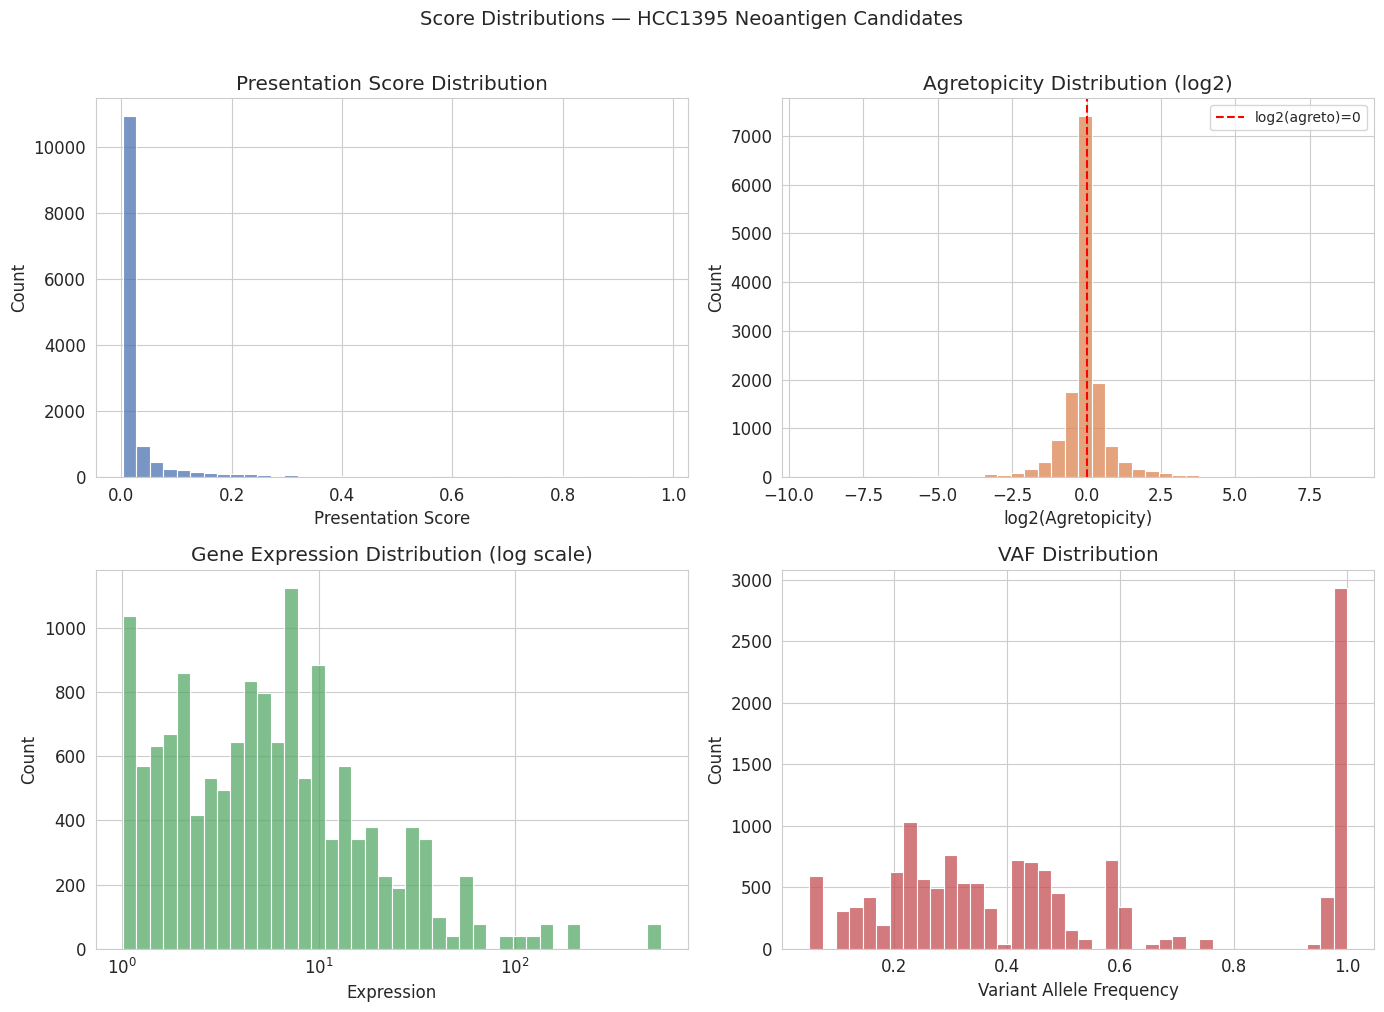

In [3]:
if df.empty:
    print("No data — skipping plots. Run notebook 04 first.")
else:
    # Identify available score columns flexibly
    pres_col   = next((c for c in df.columns if "presentation" in c.lower()), None)
    agreto_col = next((c for c in df.columns if "agretopicity" in c.lower()), None)
    expr_col   = next((c for c in df.columns if "expression"   in c.lower()), None)
    vaf_col    = next((c for c in df.columns if "vaf"          in c.lower()), None)
    print(f"Score columns found: presentation={pres_col}, agretopicity={agreto_col}, "
          f"expression={expr_col}, vaf={vaf_col}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (1) Presentation score
    ax = axes[0, 0]
    if pres_col:
        sns.histplot(df[pres_col].dropna(), bins=40, color="#4C72B0", ax=ax)
        ax.set_title("Presentation Score Distribution")
        ax.set_xlabel("Presentation Score")
        ax.set_ylabel("Count")
    else:
        ax.text(0.5, 0.5, "presentation_score not found", transform=ax.transAxes, ha="center")
        ax.set_title("Presentation Score")

    # (2) Agretopicity (log scale)
    ax = axes[0, 1]
    if agreto_col:
        agreto_pos = df[agreto_col].dropna()
        agreto_pos = agreto_pos[agreto_pos > 0]
        sns.histplot(np.log2(agreto_pos), bins=40, color="#DD8452", ax=ax)
        ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="log2(agreto)=0")
        ax.set_title("Agretopicity Distribution (log2)")
        ax.set_xlabel("log2(Agretopicity)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, "agretopicity not found", transform=ax.transAxes, ha="center")
        ax.set_title("Agretopicity")

    # (3) Expression (log scale)
    ax = axes[1, 0]
    if expr_col:
        expr_pos = df[expr_col].dropna()
        expr_pos = expr_pos[expr_pos > 0]
        if len(expr_pos) > 0:
            sns.histplot(expr_pos, bins=40, log_scale=True, color="#55A868", ax=ax)
            ax.set_title("Gene Expression Distribution (log scale)")
            ax.set_xlabel("Expression")
            ax.set_ylabel("Count")
        else:
            ax.text(0.5, 0.5, "No positive expression values", transform=ax.transAxes, ha="center")
    else:
        ax.text(0.5, 0.5, "expression not found", transform=ax.transAxes, ha="center")
        ax.set_title("Expression")

    # (4) VAF
    ax = axes[1, 1]
    if vaf_col:
        sns.histplot(df[vaf_col].dropna(), bins=40, color="#C44E52", ax=ax)
        ax.set_title("VAF Distribution")
        ax.set_xlabel("Variant Allele Frequency")
        ax.set_ylabel("Count")
    else:
        ax.text(0.5, 0.5, "vaf not found", transform=ax.transAxes, ha="center")
        ax.set_title("VAF")

    plt.suptitle("Score Distributions — HCC1395 Neoantigen Candidates", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## Volcano Plot: Agretopicity vs Presentation Score

Points in the **upper right** (high presentation score AND agretopicity > 1) are the most promising candidates.

Top candidates (presentation > 0.5 AND agretopicity > 1): 270 / 14240 (1.9%)


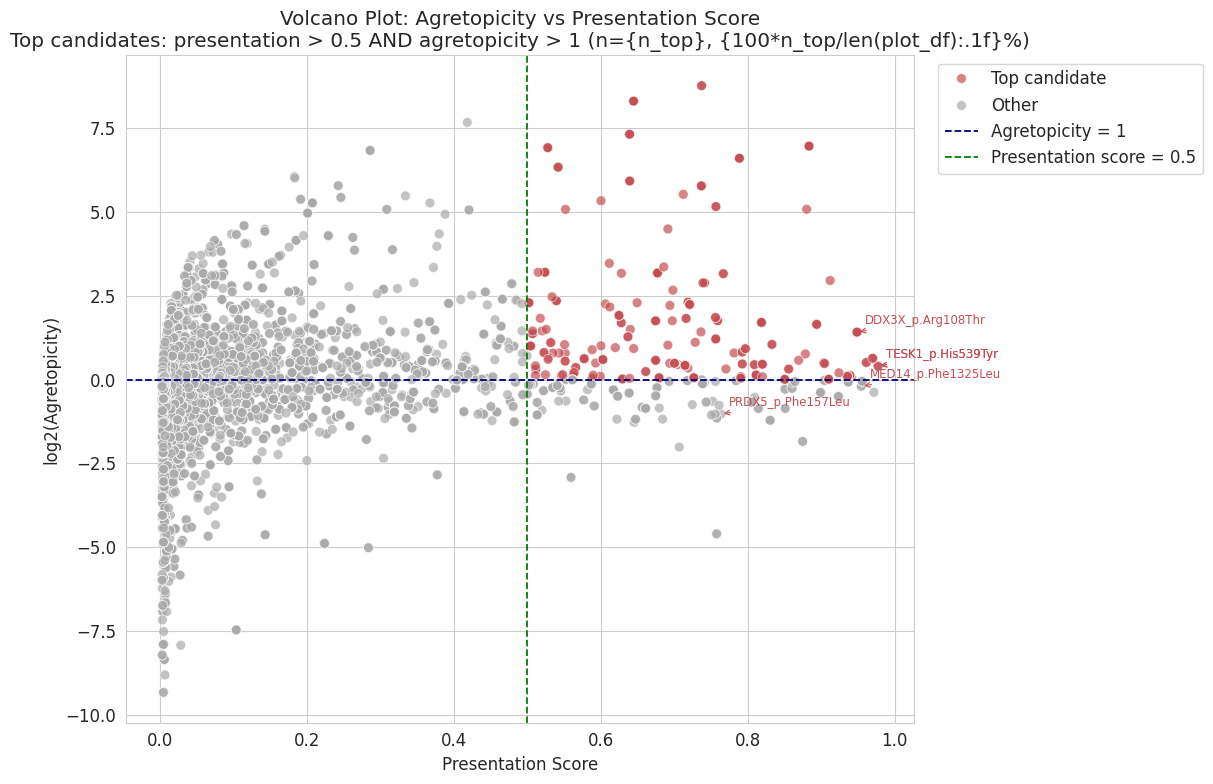

In [4]:
if not df.empty and pres_col and agreto_col:
    plot_df = df.dropna(subset=[pres_col, agreto_col]).copy()
    plot_df = plot_df[plot_df[agreto_col] > 0]
    plot_df["log2_agreto"] = np.log2(plot_df[agreto_col])

    # Field-standard threshold: presentation_score > 0.5 combined with
    # agretopicity > 1. The previous median-based threshold captured ~25% of
    # all candidates, which is too permissive. A fixed threshold of 0.5
    # corresponds roughly to the fraction of random peptides expected to be
    # presented on HLA, consistent with common neoantigen filtering practice.
    TOP_PRES_THRESHOLD = 0.5
    is_top = (plot_df[pres_col] > TOP_PRES_THRESHOLD) & (plot_df[agreto_col] > 1)
    plot_df["candidate_class"] = np.where(is_top, "Top candidate", "Other")

    n_top = is_top.sum()
    print(f"Top candidates (presentation > {TOP_PRES_THRESHOLD} AND agretopicity > 1): "
          f"{n_top} / {len(plot_df)} ({100*n_top/len(plot_df):.1f}%)")

    fig, ax = plt.subplots(figsize=(12, 8))
    palette = {"Top candidate": "#C44E52", "Other": "#aaaaaa"}
    sns.scatterplot(
        data=plot_df, x=pres_col, y="log2_agreto",
        hue="candidate_class", palette=palette,
        alpha=0.7, s=50, ax=ax
    )
    ax.axhline(0, color="navy", linestyle="--", linewidth=1.3, label="Agretopicity = 1")
    ax.axvline(TOP_PRES_THRESHOLD, color="green", linestyle="--", linewidth=1.3,
               label=f"Presentation score = {TOP_PRES_THRESHOLD}")

    # Label top 5 by composite_score or presentation_score
    rank_col = next((c for c in df.columns if "composite_score" in c.lower()), pres_col)
    gene_col = next((c for c in df.columns if "gene"      in c.lower()), None)
    mut_col  = next((c for c in df.columns if "mutation"  in c.lower()), None)

    if rank_col in plot_df.columns:
        top5 = plot_df.nlargest(5, rank_col)
        for _, row in top5.iterrows():
            label_parts = []
            if gene_col and gene_col in row.index:
                label_parts.append(str(row[gene_col]))
            if mut_col and mut_col in row.index:
                label_parts.append(str(row[mut_col]))
            label = " ".join(label_parts) if label_parts else str(row.name)
            ax.annotate(
                label,
                xy=(row[pres_col], row["log2_agreto"]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8.5, color="#C44E52",
                arrowprops=dict(arrowstyle="->", color="#C44E52", lw=0.8)
            )

    ax.set_xlabel("Presentation Score")
    ax.set_ylabel("log2(Agretopicity)")
    ax.set_title(
        f"Volcano Plot: Agretopicity vs Presentation Score\n"
        f"Top candidates: presentation > {TOP_PRES_THRESHOLD} AND agretopicity > 1 "
        f"(n={{n_top}}, {{100*n_top/len(plot_df):.1f}}%)"
    )
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient columns for volcano plot.")


## Top Candidates

In [5]:
if not df.empty:
    rank_col = next(
        (c for c in df.columns if "composite_rank" in c.lower()),
        next((c for c in df.columns if "rank" in c.lower()), None)
    )
    score_col = next((c for c in df.columns if "composite_score" in c.lower()), pres_col)

    if rank_col:
        top20 = df.nsmallest(20, rank_col)
    elif score_col:
        top20 = df.nlargest(20, score_col)
    else:
        top20 = df.head(20)

    print(f"Top 20 candidates (sorted by {rank_col or score_col or 'row order'}):")
    if score_col and score_col in top20.columns:
        styled = top20.style.background_gradient(subset=[score_col], cmap="YlOrRd")
        display(styled)
    else:
        display(top20)
else:
    print("No data — run notebook 04 first.")

Top 20 candidates (sorted by composite_rank):


KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

## Top Candidates by Gene

How many top candidates come from each gene? A gene dominating the list can indicate
expression-driven bias (highly expressed gene producing many peptides) or a genuine
mutation hotspot.

In [6]:
# 5.2 Per-gene candidate count bar chart
if not df.empty:
    gene_col = next((c for c in df.columns if c.lower() == "gene"), None)
    pres_col2 = next((c for c in df.columns if "presentation" in c.lower()), None)

    if gene_col and pres_col2:
        top_candidates = df[df[pres_col2] > 0.5] if pres_col2 else df.head(200)
        gene_counts = top_candidates[gene_col].value_counts().head(20)

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(x=gene_counts.index, y=gene_counts.values, hue=gene_counts.index,
                    palette="Blues_d", legend=False, ax=ax)
        ax.set_title(f"Top genes by candidate count (presentation > 0.5)", fontsize=13)
        ax.set_xlabel("Gene")
        ax.set_ylabel("Number of top candidates")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

        print(f"Top 10 genes contributing top candidates:")
        print(gene_counts.head(10).to_string())
    else:
        print(f"Gene or presentation_score column not found.")
else:
    print("No data — run notebook 04 first.")


Gene or presentation_score column not found.


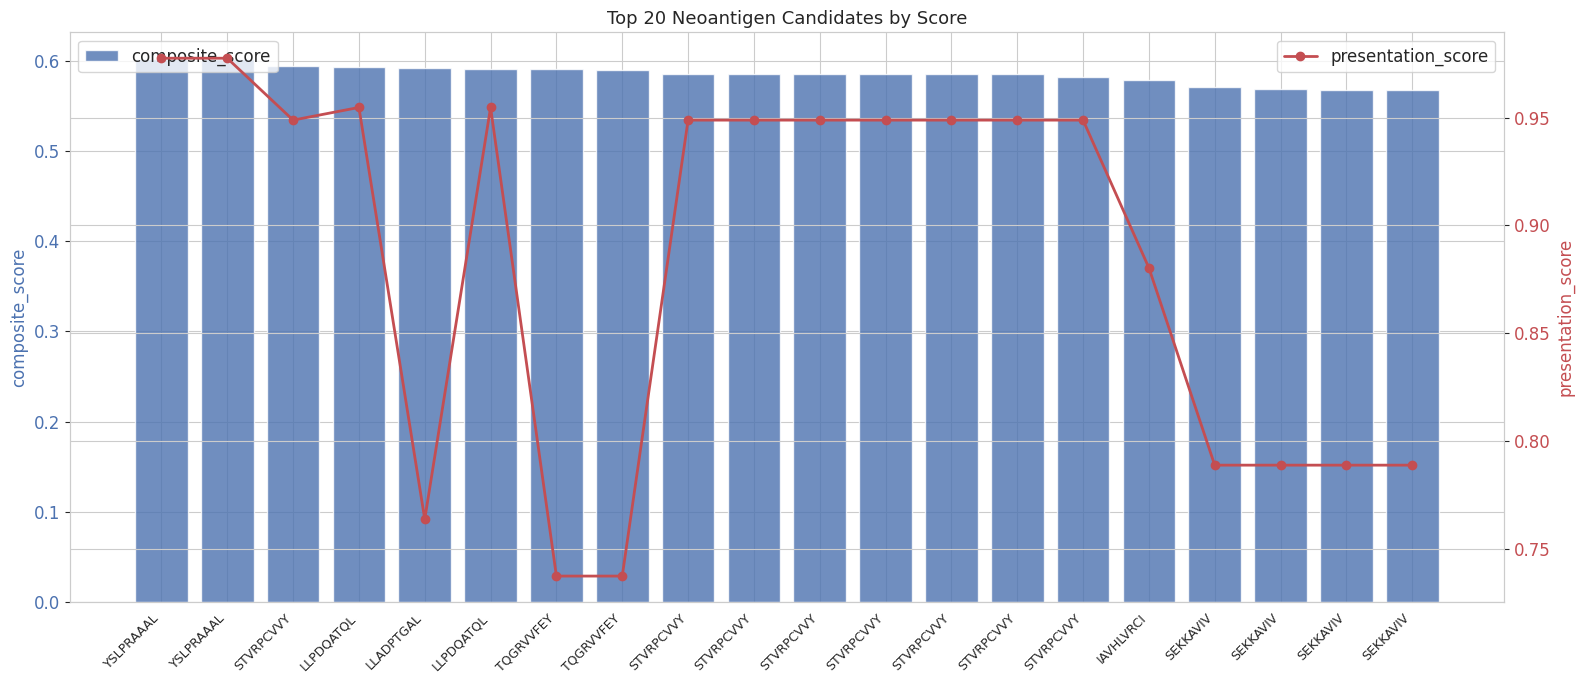

In [7]:
# Bar chart of top 20: composite_score as bar, presentation_score as line overlay
if not df.empty and len(top20) > 0:
    gene_col  = next((c for c in df.columns if c.lower() == "gene"),      None)
    mut_col   = next((c for c in df.columns if "mutation" in c.lower()),   None)
    pep_col   = next((c for c in df.columns if "peptide"  in c.lower()),   None)

    # Build x labels from gene + mutation, fallback to peptide, fallback to index
    if gene_col and mut_col and gene_col in top20.columns and mut_col in top20.columns:
        x_labels = (top20[gene_col].astype(str) + "\n" + top20[mut_col].astype(str)).tolist()
    elif pep_col and pep_col in top20.columns:
        x_labels = top20[pep_col].astype(str).tolist()
    else:
        x_labels = [str(i) for i in range(len(top20))]

    x = np.arange(len(top20))

    fig, ax1 = plt.subplots(figsize=(16, 7))

    # Bar: composite_score
    bar_col = score_col if score_col and score_col in top20.columns else pres_col
    if bar_col and bar_col in top20.columns:
        bars = ax1.bar(x, top20[bar_col].values, color="#4C72B0", alpha=0.8, label=bar_col)
        ax1.set_ylabel(bar_col, color="#4C72B0")
        ax1.tick_params(axis="y", labelcolor="#4C72B0")

    # Line overlay: presentation_score (if different from bar_col)
    if pres_col and pres_col in top20.columns and pres_col != bar_col:
        ax2 = ax1.twinx()
        ax2.plot(x, top20[pres_col].values, color="#C44E52", marker="o",
                 linewidth=2, markersize=6, label=pres_col)
        ax2.set_ylabel(pres_col, color="#C44E52")
        ax2.tick_params(axis="y", labelcolor="#C44E52")
        ax2.legend(loc="upper right")

    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
    ax1.set_title("Top 20 Neoantigen Candidates by Score", fontsize=13)
    ax1.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No data or top20 is empty.")

## Expression and Clonality

High-quality neoantigen candidates should arise from:
- **Highly expressed genes** (transcript present in tumour)
- **Clonal mutations** (high VAF — present in most tumour cells)

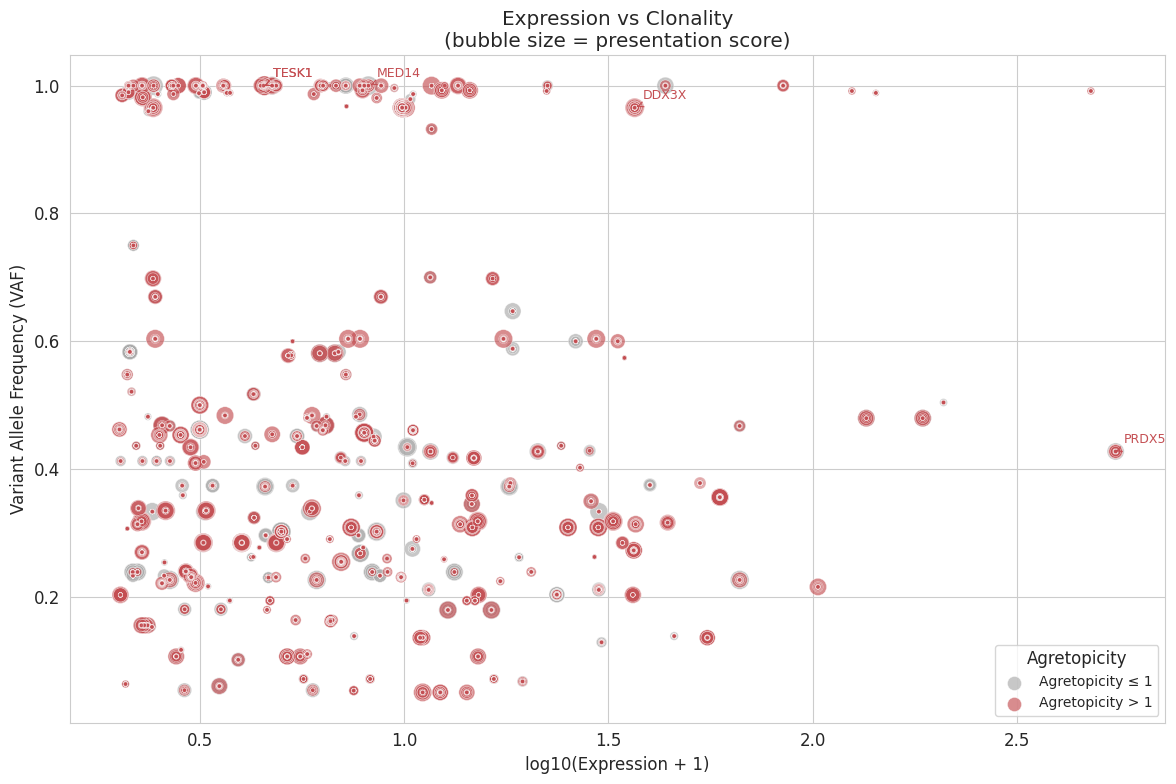

In [8]:
if not df.empty and expr_col and vaf_col and pres_col and agreto_col:
    scatter_df = df.dropna(subset=[expr_col, vaf_col, pres_col, agreto_col]).copy()
    scatter_df = scatter_df[scatter_df[expr_col] > 0]
    scatter_df["log10_expr_p1"] = np.log10(scatter_df[expr_col] + 1)
    scatter_df["is_high_agreto"] = scatter_df[agreto_col] > 1
    scatter_df["marker_size"]    = (scatter_df[pres_col] * 200).clip(lower=10, upper=300)

    fig, ax = plt.subplots(figsize=(12, 8))
    palette = {True: "#C44E52", False: "#aaaaaa"}
    for is_high, grp in scatter_df.groupby("is_high_agreto"):
        ax.scatter(
            grp["log10_expr_p1"], grp[vaf_col],
            s=grp["marker_size"],
            c=palette[is_high],
            alpha=0.65, label=f"Agretopicity {'> 1' if is_high else '≤ 1'}",
            edgecolors="white", linewidth=0.4
        )

    # Label top 5 by composite_score
    rank_col2 = score_col if score_col and score_col in scatter_df.columns else pres_col
    if rank_col2 and rank_col2 in scatter_df.columns:
        top5_scatter = scatter_df.nlargest(5, rank_col2)
        for _, row in top5_scatter.iterrows():
            label = str(row[gene_col]) if gene_col and gene_col in row.index else str(row.name)
            ax.annotate(
                label,
                xy=(row["log10_expr_p1"], row[vaf_col]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=9, color="#C44E52",
                arrowprops=dict(arrowstyle="->", color="#C44E52", lw=0.8)
            )

    ax.set_xlabel("log10(Expression + 1)")
    ax.set_ylabel("Variant Allele Frequency (VAF)")
    ax.set_title("Expression vs Clonality\n(bubble size = presentation score)")
    ax.legend(title="Agretopicity", fontsize=10)
    plt.tight_layout()
    plt.show()
elif df.empty:
    print("No data — run notebook 04 first.")
else:
    missing = [c for c, v in [
        ("expression", expr_col), ("vaf", vaf_col),
        ("presentation", pres_col), ("agretopicity", agreto_col)
    ] if not v]
    print(f"Skipping expression/clonality plot — missing columns: {missing}")
    print(f"Available: {list(df.columns)}")

## Top Candidates Summary

The highest-ranked neoantigens combine:
- **High presentation score**: predicted to be efficiently presented on HLA
- **High agretopicity**: mutant binds better than wildtype (≥1.0)
- **High expression**: gene is actively transcribed in the tumour
- **High VAF**: clonal mutation present in most tumour cells

These candidates represent the most promising targets for personalised cancer vaccines.

In [9]:
# Print top 5 candidates in a readable human-friendly format
if not df.empty:
    rank_col_final = next((c for c in df.columns if "composite_rank" in c.lower()), None)
    score_col_final = next((c for c in df.columns if "composite_score" in c.lower()), pres_col)

    if rank_col_final and rank_col_final in df.columns:
        top5 = df.nsmallest(5, rank_col_final)
    elif score_col_final and score_col_final in df.columns:
        top5 = df.nlargest(5, score_col_final)
    else:
        top5 = df.head(5)

    print("=" * 60)
    print("TOP 5 NEOANTIGEN CANDIDATES — HCC1395")
    print("=" * 60)

    for rank_i, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"\nRank {rank_i}")
        for col in df.columns:
            val = row[col]
            if pd.notna(val):
                if isinstance(val, float):
                    print(f"  {col:30s}: {val:.4f}")
                else:
                    print(f"  {col:30s}: {val}")
        print("-" * 40)
else:
    print("No data — run notebook 04 first.")

TOP 5 NEOANTIGEN CANDIDATES — HCC1395

Rank 1
  mutation                      : TESK1_p.His539Tyr
  peptide                       : YSLPRAAAL
  wildtype_peptide              : HSLPRAAAL
  best_allele                   : HLA-C*06:02
  presentation_score            : 0.9776
  binding_affinity_nm           : 50.9190
  wildtype_affinity_nm          : 67.0065
  processing_score              : 0.9012
  agretopicity                  : 1.3159
  expression                    : 3.5486
  vaf                           : 1.0000
  composite_score               : 0.6015
  composite_rank                : 1
----------------------------------------

Rank 2
  mutation                      : TESK1_p.His539Tyr
  peptide                       : YSLPRAAAL
  wildtype_peptide              : HSLPRAAAL
  best_allele                   : HLA-C*06:02
  presentation_score            : 0.9776
  binding_affinity_nm           : 50.9190
  wildtype_affinity_nm          : 67.0065
  processing_score              : 0.9012
 